In [37]:
import pandas as pd
import matplotlib.pyplot as plt
import os

In [38]:
materials = ['paper', 'glass', 'metal', 'foil', 'mirror', 'wood']
results = {}

for material in materials:
    file_path = f"{material}.csv"
    if os.path.exists(file_path):
        df = pd.read_csv(file_path)

        time_col = df.columns[0]  # Час
        lux_col = df.columns[1]  # Люкси

        # Видалення похибки
        start_time = df[time_col].min() + 2.0
        end_time = df[time_col].max() - 2.0
        clean_data = df[(df[time_col] > start_time) & (df[time_col] < end_time)]

        # Середнє
        results[material] = clean_data[lux_col].mean()

    else:
        print(f"File {file_path} does not exist.")

In [39]:
results_df = pd.DataFrame(list(results.items()), columns=['Material', 'Mean_Lux'])

# Коефіцієнт
max_lux = results_df['Mean_Lux'].max()
results_df['Coefficient'] = results_df['Mean_Lux'] / max_lux
results_df = results_df.sort_values(by='Coefficient')

In [40]:
results_df

,Material,Mean_Lux,Coefficient
4,mirror,61.200000,0.140329
5,wood,85.743802,0.196606
1,glass,96.750000,0.221843
0,paper,97.409091,0.223354
2,metal,322.928571,0.740460
3,foil,436.119048,1.000000


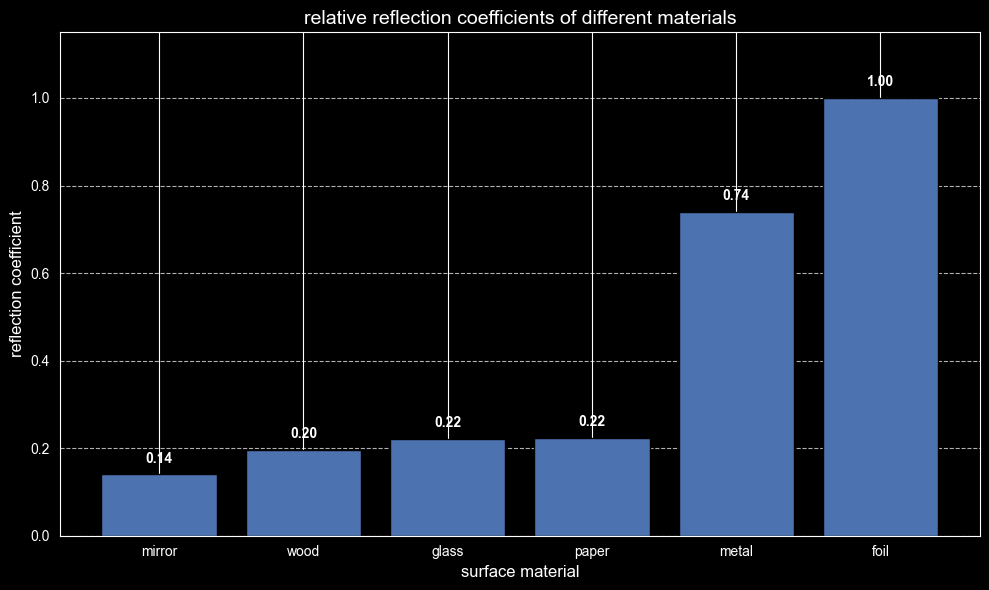

In [44]:
plt.figure(figsize=(10, 6))
bars = plt.bar(results_df['Material'], results_df['Coefficient'], color='#4C72B0', edgecolor='black')

plt.title('relative reflection coefficients of different materials', fontsize=14)
plt.xlabel('surface material', fontsize=12)
plt.ylabel('reflection coefficient', fontsize=12)
plt.ylim(0, 1.15)
plt.grid(axis='y', linestyle='--', alpha=0.7)

for bar in bars:
    y_val = bar.get_height()
    plt.text(bar.get_x() + bar.get_width() / 2, y_val + 0.02,
             f"{y_val:.2f}", ha='center', va='bottom', fontweight='bold')

plt.tight_layout()
plt.show()